### 1. Limpieza y comprensión de datos.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
df = pd.read_csv("wbes_sintetico.csv")
cols = [
    "sales_annual_usd",
    "labor_productivity_usd_per_employee",
    "employees",
    "firm_age_years",
    "training",
    "access_finance",
    "exporter",
    "competition_level",
    "digital_payments",
]

completeDf = df[cols]

DfNoNull = completeDf.dropna()

DfNoNull.shape


(1046, 9)

In [13]:
x_train = np.array(DfNoNull['sales_annual_usd']).reshape(-1,1)
y_train = np.array(DfNoNull['labor_productivity_usd_per_employee']).reshape(-1,1)

### Aplicar regresión lineal

In [ ]:
r = linear_model.LinearRegression()

r.fit(x_train, y_train)

y_pred = r.predict(x_train)

print('Coeficiente de correlación: ', r.coef_)
print('Interseccion: ', r.intercept_)
print('Error cuadrático de la media: ', mean_squared_error(y_train, y_pred))
print('Varianza: ', r2_score(y_train, y_pred))

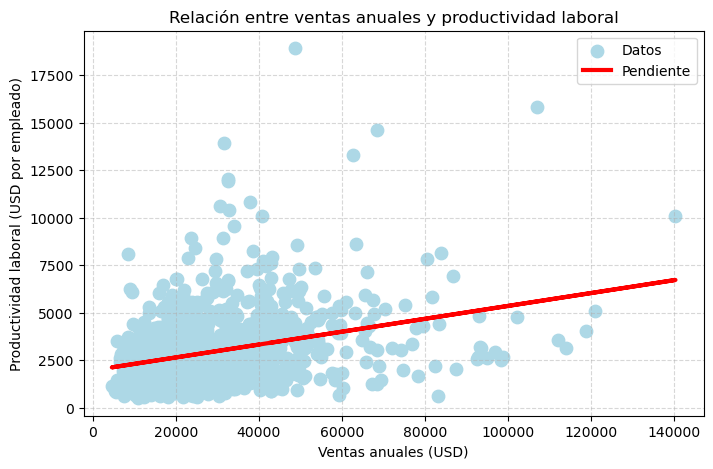

In [19]:
x = x_train.ravel()
y = y_train.ravel()

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='lightblue', s=80, label='Datos')
plt.plot(x, y_pred, color='red', linewidth=3, label='Pendiente')
plt.xlabel('Ventas anuales (USD)')
plt.ylabel('Productividad laboral (USD por empleado)')
plt.title('Relación entre ventas anuales y productividad laboral')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()